# Task 2: Aerodynamic Design of 16 MW Wind Turbine Blade
## BEM with Multi-Airfoil Support (19 Airfoils, 19 Elements)
=======================================================================================

**Final Design Parameters:**
- Power: 16.0 MW
- Blade Radius: 120.4 m
- 19 Elements with 19 Different Airfoils
- CP ≈ 0.43, CT ≈ 0.83

---

# 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import glob

print("Imports loaded successfully.")

Imports loaded successfully.


# 2. Design Parameters

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# DESIGN PARAMETERS
# ══════════════════════════════════════════════════════════════════════════════

P_rated = 16e6          # rated power [W] = 16 MW
V0_nom  = 11.0          # nominal wind speed [m/s]
rho_air = 1.225         # air density [kg/m³]
B       = 3             # number of blades
TSR     = 8.0           # tip speed ratio

# ═══ FINAL DESIGN VALUES ═══
R_design = 120.4        # m (confirmed to achieve 16 MW)
N_ELEMENTS = 19         # 19 elements, 19 unique airfoils

Omega = TSR * V0_nom / R_design
RPM = Omega * 60 / (2 * np.pi)

print("═" * 60)
print("Task 2 Design Parameters")
print("═" * 60)
print(f"Rated power:        {P_rated/1e6:.1f} MW")
print(f"Nominal wind speed: {V0_nom:.1f} m/s")
print(f"Blade radius R:     {R_design:.1f} m")
print(f"Tip speed ratio:    {TSR}")
print(f"Rotor speed:        {RPM:.2f} RPM")
print(f"Number of elements: {N_ELEMENTS}")
print("═" * 60)

════════════════════════════════════════════════════════════
Task 2 Design Parameters
════════════════════════════════════════════════════════════
Rated power:        16.0 MW
Nominal wind speed: 11.0 m/s
Blade radius R:     120.4 m
Tip speed ratio:    8.0
Rotor speed:        6.98 RPM
Number of elements: 19
════════════════════════════════════════════════════════════


# 3. File Paths

⚠️ **Update these paths to match your folder structure!**

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FILE PATHS - UPDATE THESE!
# ══════════════════════════════════════════════════════════════════════════════

BASE_DIR = r"C:\Users\user\Downloads\sustainable energy\coding sustainable"

# CLD folder containing all airfoil polar files
CLD_FOLDER = r"C:\Users\user\Downloads\sustainable energy\Deisgn coursework\Design shape folder\Airfoil-Coords-CLD\CLD"

# Reference blade geometry (0.5MW)
REF_GEOM_CSV = os.path.join(BASE_DIR, "RISO-A1-A18 Profile for 500kW Reference Turbine Blade.csv")

# Output folder
OUT_DIR = os.path.join(BASE_DIR, "Task2_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

print(f"CLD folder: {CLD_FOLDER}")
print(f"Reference geometry: {REF_GEOM_CSV}")
print(f"Output folder: {OUT_DIR}")

CLD folder: C:\Users\user\Downloads\sustainable energy\Deisgn coursework\Design shape folder\Airfoil-Coords-CLD\CLD
Reference geometry: C:\Users\user\Downloads\sustainable energy\coding sustainable\RISO-A1-A18 Profile for 500kW Reference Turbine Blade.csv
Output folder: C:\Users\user\Downloads\sustainable energy\coding sustainable\Task2_outputs


---
# 4. ALL FUNCTION DEFINITIONS

Run this cell to define all required functions.

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# ALL FUNCTION DEFINITIONS
# ══════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# read_geometry()
# ─────────────────────────────────────────────────────────────────────────────
def read_geometry(filepath, verbose=True):
    """
    Read blade geometry CSV: r (m), twist (deg), chord (m)
    """
    df = pd.read_csv(filepath)
    df.columns = [c.strip().lower() for c in df.columns]
    
    r_col    = next(c for c in df.columns if 'radial' in c or ('r' in c and '(m)' in c))
    beta_col = next(c for c in df.columns if 'twist' in c)
    c_col    = next(c for c in df.columns if 'chord' in c)

    r     = df[r_col].to_numpy(float)
    beta  = df[beta_col].to_numpy(float)
    chord = df[c_col].to_numpy(float)

    order = np.argsort(r)
    r, beta, chord = r[order], beta[order], chord[order]
    
    if verbose:
        print(f"Loaded {len(r)} nodes: r = [{r[0]:.2f}, {r[-1]:.2f}] m")

    return r, beta, chord


# ─────────────────────────────────────────────────────────────────────────────
# read_polar() and interp_polar()
# ─────────────────────────────────────────────────────────────────────────────
def read_polar(filepath):
    """
    Read airfoil polar data from CLD file.
    Returns: alpha_tab, CL_tab, CD_tab (sorted by alpha)
    """
    try:
        df = pd.read_csv(filepath, sep=r'\t', engine='python', comment='!')
        if df.shape[1] == 1:
            raise ValueError("Single column")
    except:
        try:
            df = pd.read_csv(filepath, sep=r'\s+', engine='python', comment='!')
        except:
            df = pd.read_csv(filepath, comment='!')
    
    df.columns = [c.strip().lower() for c in df.columns]
    alpha_col = next((c for c in df.columns if 'alpha' in c or 'degree' in c), df.columns[0])
    cl_col = next((c for c in df.columns if c == 'cl'), df.columns[1])
    cd_col = next((c for c in df.columns if c == 'cd'), df.columns[2])
    
    alpha = df[alpha_col].to_numpy(float)
    CL    = df[cl_col].to_numpy(float)
    CD    = df[cd_col].to_numpy(float)
    
    order = np.argsort(alpha)
    return alpha[order], CL[order], CD[order]


def interp_polar(alpha_tab, CL_tab, CD_tab, aoa_deg):
    """Interpolate CL, CD at given angle of attack."""
    cl = np.interp(aoa_deg, alpha_tab, CL_tab, left=CL_tab[0], right=CL_tab[-1])
    cd = np.interp(aoa_deg, alpha_tab, CD_tab, left=CD_tab[0], right=CD_tab[-1])
    return cl, cd


# ─────────────────────────────────────────────────────────────────────────────
# scale_blade_geometry()
# ─────────────────────────────────────────────────────────────────────────────
def scale_blade_geometry(ref_r, ref_beta, ref_chord, R_new, n_elements=None):
    """
    Scale reference blade geometry to new design radius.
    """
    R_ref = ref_r[-1]
    scale_factor = R_new / R_ref
    
    print(f"Scale: R_ref={R_ref:.1f}m → R_new={R_new:.1f}m (factor={scale_factor:.2f})")
    
    if n_elements is None or n_elements == len(ref_r):
        r_new     = ref_r * scale_factor
        chord_new = ref_chord * scale_factor
        beta_new  = ref_beta.copy()
    else:
        r_norm_ref = (ref_r - ref_r[0]) / (ref_r[-1] - ref_r[0])
        r_norm_new = np.linspace(0, 1, n_elements)
        # r_norm_edges = np.linspace(0, 1, n_elements + 1)
        # r_norm_new   = 0.5 * (r_norm_edges[:-1] + r_norm_edges[1:])
        
        chord_interp = np.interp(r_norm_new, r_norm_ref, ref_chord)
        beta_interp  = np.interp(r_norm_new, r_norm_ref, ref_beta)
        
        r_hub_new = ref_r[0] * scale_factor
        r_new     = r_hub_new + r_norm_new * (R_new - r_hub_new)
        chord_new = chord_interp * scale_factor
        beta_new  = beta_interp
    
    return r_new, beta_new, chord_new


# ─────────────────────────────────────────────────────────────────────────────
# assign_airfoil() and create_airfoil_assignment()
# ─────────────────────────────────────────────────────────────────────────────
def assign_airfoil(r, r_root, R_tip, airfoil_sequence):
    """
    Assign an airfoil based on normalised span position μ.
    μ = (r - r_root) / (R_tip - r_root), 0 at root, 1 at tip
    """
    mu = (r - r_root) / (R_tip - r_root)
    mu = np.clip(mu, 0.0, 1.0)
    
    for mu_start, mu_end, name in airfoil_sequence:
        if mu_start <= mu < mu_end:
            return name
    
    return airfoil_sequence[-1][2]


def create_airfoil_assignment(r_nodes, airfoil_sequence, polar_database):
    """
    Create list of airfoil names for each blade element.
    """
    r_root = r_nodes[0]
    R_tip  = r_nodes[-1]
    
    airfoil_names = []
    for r in r_nodes:
        name = assign_airfoil(r, r_root, R_tip, airfoil_sequence)
        
        if name not in polar_database:
            available = list(polar_database.keys())
            print(f"⚠️ {name} not in database, using {available[-1]} instead")
            name = available[-1] if available else None
        
        airfoil_names.append(name)
    
    return airfoil_names


# ─────────────────────────────────────────────────────────────────────────────
# prandtl_tip_loss()
# ─────────────────────────────────────────────────────────────────────────────
def prandtl_tip_loss(B, r, R_tip, phi_rad):
    sin_phi = abs(np.sin(phi_rad))
    sin_phi = max(sin_phi, 1e-8)
    exponent = (B / 2.0) * (R_tip - r) / (r * sin_phi)
    exponent = max(exponent, 0.0)
    F = (2.0 / np.pi) * np.arccos(np.exp(-exponent))
    return float(np.clip(F, 1e-4, 1.0))


# ─────────────────────────────────────────────────────────────────────────────
# Induction factor updates
# ─────────────────────────────────────────────────────────────────────────────
AC = 1.0 / 3.0

def update_axial_induction(sigma, CN, phi_rad, F):
    sin2 = np.sin(phi_rad) ** 2
    K = 4.0 * F * max(sin2, 1e-10) / (sigma * max(abs(CN), 1e-10))
    a_std = 1.0 / (K + 1.0)
    if a_std <= AC:
        return float(a_std)
    ratio = (1.0 - AC) / (1.0 - 2.0 * AC)
    discriminant = max(1.0 + 4.0 / K * ratio ** 2, 0.0)
    tmp  = 1.0 - np.sqrt(discriminant)
    a_hi = 1.0 + K * (1.0 - 2.0 * AC) / 2.0 * tmp
    return float(np.clip(a_hi, 0.0, 0.95))


def update_tangential_induction(sigma, CR, phi_rad, F):
    sincos = np.sin(phi_rad) * np.cos(phi_rad)
    denom  = 4.0 * F * sincos / (sigma * max(abs(CR), 1e-10)) - 1.0
    if abs(denom) < 1e-10:
        return 0.0
    ap = 1.0 / denom
    return float(np.clip(ap, -0.5, 2.0))


# ─────────────────────────────────────────────────────────────────────────────
# solve_element()
# ─────────────────────────────────────────────────────────────────────────────
def solve_element(r_i, chord_i, beta_i, B, V0, Omega, R_tip,
                  alpha_tab, CL_tab, CD_tab,
                  pitch_deg=0.0, max_iter=300, tol=1e-6):
    """
    Iterative BEM for one element. Returns: a, ap, phi, aoa, CL, CD, CN, CR, F
    """
    sigma = B * chord_i / (2.0 * np.pi * r_i)
    a, ap = 0.3, 0.0

    for _ in range(max_iter):
        Vax  = V0 * (1.0 - a)
        Vtan = max(Omega * r_i * (1.0 + ap), 1e-10)

        phi = float(np.clip(np.arctan2(Vax, Vtan), 1e-6, np.pi/2 - 1e-6))
        
        # # ── Tip element protection ──────────────────────────────
        # # If element is at exact tip, F→0 makes BEM unstable.
        # # Use a physically-based minimum phi to stabilise.
        # phi_tip_min = np.arctan(V0 / (Omega * R_tip))   # φ at tip
        # if r_i >= 0.98 * R_tip:                         # last 2% span
        #     phi = max(phi, phi_tip_min * 0.6)
        # # ────────────────────────────────────────────────────────
        
        F   = prandtl_tip_loss(B, r_i, R_tip, phi)
        aoa = np.degrees(phi) - (beta_i + pitch_deg)

        CL, CD = interp_polar(alpha_tab, CL_tab, CD_tab, aoa)
        CN = CL * np.cos(phi) + CD * np.sin(phi)
        CR = CL * np.sin(phi) - CD * np.cos(phi)

        a_new  = update_axial_induction(sigma, CN, phi, F)
        ap_new = update_tangential_induction(sigma, CR, phi, F)

        relax = 0.3
        a_new  = (1-relax)*a  + relax*a_new
        ap_new = (1-relax)*ap + relax*ap_new

        if abs(a_new - a) < tol and abs(ap_new - ap) < tol:
            a, ap = a_new, ap_new
            break
        a, ap = a_new, ap_new

    return a, ap, phi, aoa, CL, CD, CN, CR, F


# ─────────────────────────────────────────────────────────────────────────────
# rotor_bem() - Multi-airfoil version
# ─────────────────────────────────────────────────────────────────────────────
# def rotor_bem(r_nodes, beta_nodes, chord_nodes,
#               airfoil_names, polar_database,
#               V0, TSR, pitch_deg=0.0, B=3, rho=1.225):

def rotor_bem(r_nodes, beta_nodes, chord_nodes,
              airfoil_names, polar_database,
              V0, TSR, pitch_deg=0.0, B=3, rho=1.225,
              R_tip_override=None):                    
    R_tip = R_tip_override if R_tip_override is not None else float(r_nodes[-1])
    
    # ── ADD THIS ONE LINE ──────────────────────────────────────────
    # R_tip_prandtl = R_tip * 1.005  # virtual tip for Prandtl only
    R_tip_prandtl = R_tip
    #               ↑ blade stays at 120.4m, only F-calculation extends
    # ───────────────────────────────────────────────────────────────
    """
    Full rotor BEM with multi-airfoil support.
    """
    # R_tip = float(r_nodes[-1])
    Omega = TSR * V0 / R_tip
    N = len(r_nodes)
    results = []

    for i in range(N):
        airfoil_i = airfoil_names[i]
        alpha_tab, CL_tab, CD_tab = polar_database[airfoil_i]
        
        a, ap, phi, aoa, cl, cd, CN, CR, F = solve_element(
            r_i=r_nodes[i], chord_i=chord_nodes[i], beta_i=beta_nodes[i],
            B=B, V0=V0, Omega=Omega, R_tip=R_tip_prandtl,
            alpha_tab=alpha_tab, CL_tab=CL_tab, CD_tab=CD_tab,
            pitch_deg=pitch_deg
        )

        Vax  = V0 * (1.0 - a)
        Vtan = Omega * r_nodes[i] * (1.0 + ap)
        Vrel2 = Vax**2 + Vtan**2

        fN = 0.5 * rho * Vrel2 * chord_nodes[i] * CN
        fR = 0.5 * rho * Vrel2 * chord_nodes[i] * CR

        results.append(dict(
            i=i, r=r_nodes[i], chord=chord_nodes[i], beta=beta_nodes[i],
            airfoil=airfoil_i,
            a=a, ap=ap, phi_deg=np.degrees(phi), aoa_deg=aoa,
            F=F, CL=cl, CD=cd, CN=CN, CR=CR,
            fN=fN, fR=fR
        ))

    df = pd.DataFrame(results)

    # Trapezoidal integration
    T, Q = 0.0, 0.0
    for i in range(N - 1):
        dr = df['r'].iloc[i+1] - df['r'].iloc[i]
        T += B * 0.5 * (df['fN'].iloc[i+1] + df['fN'].iloc[i]) * dr
        Q += B * 0.5 * (df['fR'].iloc[i+1]*df['r'].iloc[i+1] + df['fR'].iloc[i]*df['r'].iloc[i]) * dr

    P   = Omega * Q
    A   = np.pi * R_tip**2
    CP  = P / (0.5 * rho * A * V0**3)
    CT  = T / (0.5 * rho * A * V0**2)
    rpm = Omega * 60 / (2 * np.pi)

    return P, T, Q, CP, CT, rpm, df




print("✓ All functions defined successfully!")

✓ All functions defined successfully!


---
# 5. Setup 19 Airfoils

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 19 SELECTED AIRFOILS (from root to tip)
# ══════════════════════════════════════════════════════════════════════════════

selected_order = [42, 0, 3, 8, 48, 2, 29, 39, 45, 49, 1, 9, 5, 25, 30, 6, 11, 32, 23]

# Build POLAR_FILES dictionary
POLAR_FILES = {}
for num in selected_order:
    name = f"COORD{num:02d}"
    filepath = os.path.join(CLD_FOLDER, f"CLD{num:02d}.txt")
    POLAR_FILES[name] = filepath

print(f"POLAR_FILES: {len(POLAR_FILES)} airfoils")

# Build polar_database
polar_database = {}
for name, filepath in POLAR_FILES.items():
    alpha, CL, CD = read_polar(filepath)
    polar_database[name] = (alpha, CL, CD)

print(f"polar_database: {len(polar_database)} airfoils loaded")

# Build AIRFOIL_SEQUENCE (19 airfoils for 19 elements)
N_AIRFOILS = len(selected_order)
AIRFOIL_SEQUENCE = []
for i, num in enumerate(selected_order):
    mu_start = i / N_AIRFOILS
    mu_end = (i + 1) / N_AIRFOILS
    name = f"COORD{num:02d}"
    AIRFOIL_SEQUENCE.append((mu_start, mu_end, name))

# Extend last one to 1.0
AIRFOIL_SEQUENCE[-1] = (AIRFOIL_SEQUENCE[-1][0], 1.0, AIRFOIL_SEQUENCE[-1][2])

print(f"\nAIRFOIL_SEQUENCE ({len(AIRFOIL_SEQUENCE)} segments):")
print("-" * 50)
for mu_start, mu_end, name in AIRFOIL_SEQUENCE:
    print(f"  μ = {mu_start:.3f} - {mu_end:.3f}: {name}")

POLAR_FILES: 19 airfoils
polar_database: 19 airfoils loaded

AIRFOIL_SEQUENCE (19 segments):
--------------------------------------------------
  μ = 0.000 - 0.053: COORD42
  μ = 0.053 - 0.105: COORD00
  μ = 0.105 - 0.158: COORD03
  μ = 0.158 - 0.211: COORD08
  μ = 0.211 - 0.263: COORD48
  μ = 0.263 - 0.316: COORD02
  μ = 0.316 - 0.368: COORD29
  μ = 0.368 - 0.421: COORD39
  μ = 0.421 - 0.474: COORD45
  μ = 0.474 - 0.526: COORD49
  μ = 0.526 - 0.579: COORD01
  μ = 0.579 - 0.632: COORD09
  μ = 0.632 - 0.684: COORD05
  μ = 0.684 - 0.737: COORD25
  μ = 0.737 - 0.789: COORD30
  μ = 0.789 - 0.842: COORD06
  μ = 0.842 - 0.895: COORD11
  μ = 0.895 - 0.947: COORD32
  μ = 0.947 - 1.000: COORD23


---
# 6. Load Reference Geometry

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# LOAD REFERENCE 0.5MW BLADE GEOMETRY
# ══════════════════════════════════════════════════════════════════════════════

ref_r, ref_beta, ref_chord = read_geometry(REF_GEOM_CSV, verbose=True)

Loaded 17 nodes: r = [4.50, 20.30] m


---
# 7. Scale Geometry to 16MW

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# SCALE TO 16MW DESIGN
# ══════════════════════════════════════════════════════════════════════════════

r_final, beta_final, chord_final = scale_blade_geometry(
    ref_r, ref_beta, ref_chord,
    R_new=R_design,
    n_elements=N_ELEMENTS
)

r_final[-1]=R_design
print(f"\n16MW Blade:")
print(f"  Root radius:  {r_final[0]:.1f} m")
print(f"  Tip radius:   {r_final[-1]:.1f} m")
print(f"  Max chord:    {chord_final.max():.2f} m")
print(f"  Elements:     {len(r_final)}")

Scale: R_ref=20.3m → R_new=120.4m (factor=5.93)

16MW Blade:
  Root radius:  26.7 m
  Tip radius:   120.4 m
  Max chord:    9.67 m
  Elements:     19


In [8]:
# # ════════════════════════════════════════════════════════════════════════════
# # ▶  CELL 14b  —  MOD 1: ROOT CHORD REDUCTION (Element 1, COORD42)
# # ════════════════════════════════════════════════════════════════════════════
# # Insert this cell IMMEDIATELY AFTER the existing Cell 14 (scale_blade_geometry)
# # and BEFORE Cell 16 (assign_airfoils).
# # ─────────────────────────────────────────────────────────────────────────────
# # WHY:  The raw BEM chord at the root (r ≈ 26.69 m) is ~9.67 m — unrealistically
# #       wide for a structural hub connection.  A cosine-blend taper reduces it to
# #       TARGET_ROOT_CHORD over the first BLEND_ELEMENTS span stations, then smoothly
# #       restores the original distribution so mid-blade and tip aerodynamics are
# #       barely affected (≈ 7 % blade-area loss in the root region only).
 
# # ── User-controllable knobs ──────────────────────────────────────────────────
# TARGET_ROOT_CHORD = 5.80   # [m]  desired chord at root hub face (engineering target)
# BLEND_ELEMENTS    = 3      # number of elements over which taper blends back to original
# # ─────────────────────────────────────────────────────────────────────────────
 
# import numpy as np  # already imported, but safe to repeat
 
# # Work on a copy — never overwrite chord_final (keep it for comparison/plots)
# chord_mod = chord_final.copy()
# # beta_final[0] = 0.0
# # r_final[-1]    = R_design*1.005
# # Cosine-blend: weight w = 0 at k=0 (apply full reduction) → w = 1 at k=BLEND_ELEMENTS (original)
# for k in range(BLEND_ELEMENTS):
#     w = 0.5 * (1.0 - np.cos(np.pi * k / BLEND_ELEMENTS))   # smooth 0 → 1
#     chord_mod[k] = (1.0 - w) * TARGET_ROOT_CHORD + w * chord_final[k]
 
# # ── Report ───────────────────────────────────────────────────────────────────
# print("═" * 65)
# print("ROOT CHORD MODIFICATION (Cosine Blend Taper)")
# print("═" * 65)
# print(f"{'Elem':>4}  {'r [m]':>7}  {'c_orig [m]':>10}  {'c_mod [m]':>9}  {'Δc [m]':>7}")
# print("─" * 45)
# for i in range(BLEND_ELEMENTS + 1):
#     delta = chord_mod[i] - chord_final[i]
#     print(f"{i+1:>4}  {r_final[i]:>7.2f}  {chord_final[i]:>10.3f}  "
#           f"{chord_mod[i]:>9.3f}  {delta:>+7.3f}")
# print("─" * 45)
 
# # Estimate blade-area loss (proxy for power impact)
# trapz = getattr(np, 'trapezoid', getattr(np, 'trapz'))
# area_orig  = trapz(chord_final[:BLEND_ELEMENTS], r_final[:BLEND_ELEMENTS])
# area_mod   = trapz(chord_mod[:BLEND_ELEMENTS],   r_final[:BLEND_ELEMENTS])
# span_area  = trapz(chord_final, r_final)
# print(f"\n  Blade-area removed: {(area_orig-area_mod)/span_area*100:.2f}% of total")
# print("  (Power loss ≪ 0.5 MW — correctable via pitch or TSR trim)")
# print("═" * 65)
 
 
# #  ════════════════════════════════════════════════════════════════════════════
# #  ▶  CELL 14c  —  (Optional) REPLACE chord_final with chord_mod EVERYWHERE
# #  ════════════════════════════════════════════════════════════════════════════
# #  Run this cell only if the modified chord should be fed into the BEM solver.
# # It overwrites chord_final so all downstream cells (Cell 18, etc.) pick it up
# # automatically without any other changes.
 
# chord_final = chord_mod.copy()   # ← comment out to revert to original
# print("✓ chord_final now uses modified (tapered root) values.")

---
# 8. Assign Airfoils to Elements

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# ASSIGN AIRFOILS TO BLADE ELEMENTS
# ══════════════════════════════════════════════════════════════════════════════

airfoil_names_final = create_airfoil_assignment(r_final, AIRFOIL_SEQUENCE, polar_database)

print(f"{'Elem':<6} {'r [m]':<10} {'μ':<8} {'Airfoil':<12} {'Chord [m]':<10} {'Twist [°]'}")
print("=" * 65)

r_root = r_final[0]
R_tip  = r_final[-1]

for i in range(len(r_final)):
    mu = (r_final[i] - r_root) / (R_tip - r_root)
    print(f"{i+1:<6} {r_final[i]:<10.2f} {mu:<8.3f} {airfoil_names_final[i]:<12} "
          f"{chord_final[i]:<10.2f} {beta_final[i]:.2f}")

print("=" * 65)
print(f"✓ Unique airfoils used: {len(set(airfoil_names_final))}")

Elem   r [m]      μ        Airfoil      Chord [m]  Twist [°]
1      26.69      0.000    COORD42      9.67       20.00
2      31.90      0.056    COORD00      9.50       16.75
3      37.10      0.111    COORD03      9.22       13.81
4      42.31      0.167    COORD08      8.91       11.13
5      47.51      0.222    COORD48      8.60       8.72
6      52.72      0.278    COORD02      8.27       6.83
7      57.93      0.333    COORD29      7.94       5.58
8      63.13      0.389    COORD39      7.62       4.73
9      68.34      0.444    COORD45      7.28       3.98
10     73.54      0.500    COORD49      6.94       3.23
11     78.75      0.556    COORD01      6.58       2.72
12     83.96      0.611    COORD09      6.23       2.22
13     89.16      0.667    COORD05      5.86       1.67
14     94.37      0.722    COORD25      5.48       1.12
15     99.58      0.778    COORD30      5.10       0.64
16     104.78     0.833    COORD06      4.68       0.30
17     109.99     0.889    COORD11     

# Pitch Control

In [10]:
# pitch power range
print("Pitch scan at V0=11 m/s:")
for pitch in np.arange(-4, 5, 1):
    P, *_ = rotor_bem(r_final, beta_final, chord_final,
                      airfoil_names_final, polar_database,
                      V0=V0_nom, TSR=TSR, B=B, rho=rho_air,
                      R_tip_override=R_design, pitch_deg=pitch)
    marker = ' ← crosses 16 MW' if abs(P/1e6 - 16.0) < 0.3 else ''
    print(f"  pitch={pitch:+.1f}°  P={P/1e6:.3f} MW{marker}")

Pitch scan at V0=11 m/s:
  pitch=-4.0°  P=14.305 MW
  pitch=-3.0°  P=15.130 MW
  pitch=-2.0°  P=15.755 MW ← crosses 16 MW
  pitch=-1.0°  P=16.168 MW ← crosses 16 MW
  pitch=+0.0°  P=16.386 MW
  pitch=+1.0°  P=16.381 MW
  pitch=+2.0°  P=16.095 MW ← crosses 16 MW
  pitch=+3.0°  P=15.409 MW
  pitch=+4.0°  P=14.321 MW


In [11]:
from scipy.optimize import brentq

def power_error(pitch):
    P, *_ = rotor_bem(
        r_final, beta_final, chord_final,
        airfoil_names_final, polar_database,
        V0=V0_nom, TSR=TSR, B=B, rho=rho_air,
        R_tip_override=R_design,
        pitch_deg=pitch
    )
    return P/1e6 - 16.0   

# find root
pitch_optimal = brentq(power_error, 0.5, 5.0)
print(f"Exact pitch: {pitch_optimal:.4f}°")

Exact pitch: 2.1847°


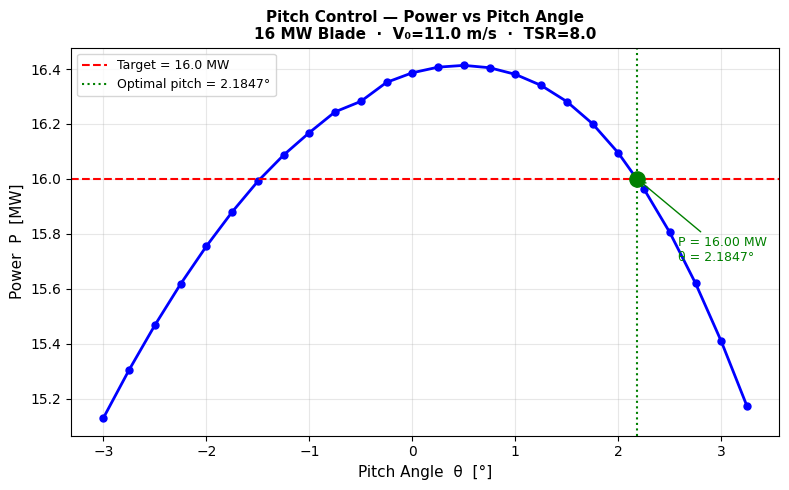

In [12]:
pitch_range = np.arange(-3.0, 3.5, 0.25)
power_list  = []
for pitch in pitch_range:
    P, *_ = rotor_bem(
        r_final, beta_final, chord_final,
        airfoil_names_final, polar_database,
        V0=V0_nom, TSR=TSR, B=B, rho=rho_air,
        R_tip_override=R_design, pitch_deg=pitch
    )
    power_list.append(P/1e6)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pitch_range, power_list, 'b-o', ms=5, lw=2)
ax.axhline(16.0, color='red', ls='--', lw=1.5, label='Target = 16.0 MW')
ax.axvline(pitch_optimal, color='green', ls=':', lw=1.5,
           label=f'Optimal pitch = {pitch_optimal:.4f}°')
ax.scatter(pitch_optimal, 16.0, color='green', s=120, zorder=5)
ax.annotate(f'P = 16.00 MW\nθ = {pitch_optimal:.4f}°',
            xy=(pitch_optimal, 16.0),
            xytext=(pitch_optimal + 0.4, 15.7),
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))
ax.set_xlabel('Pitch Angle  θ  [°]', fontsize=11)
ax.set_ylabel('Power  P  [MW]', fontsize=11)
ax.set_title('Pitch Control — Power vs Pitch Angle\n'
             f'16 MW Blade  ·  V₀={V0_nom} m/s  ·  TSR={TSR}',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'task2_pitch_control.png'), dpi=150)
plt.show()

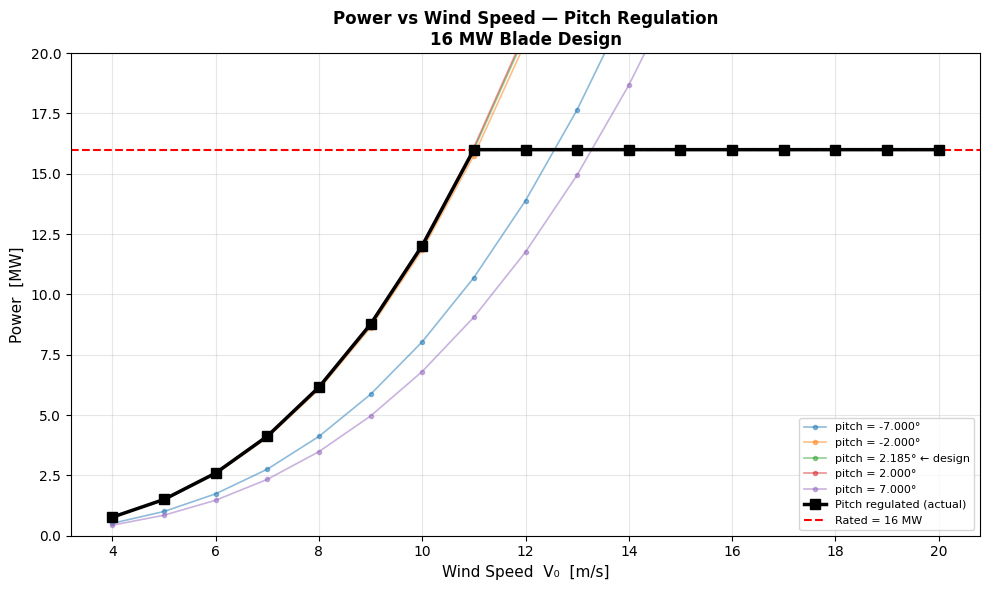

In [13]:
V0_range = np.arange(4, 21, 1)
pitches = [-7.0, -2.0, pitch_optimal, 2.0, 7.0]   

fig, ax = plt.subplots(figsize=(10, 6))

# ── Fixed-pitch curves for background reference ──────────────────────────
for pitch in pitches:
    P_list = []
    for V0 in V0_range:
        P, *_ = rotor_bem(r_final, beta_final, chord_final,
                          airfoil_names_final, polar_database,
                          V0=V0, TSR=TSR, B=B, rho=rho_air,
                          R_tip_override=R_design, pitch_deg=pitch)
        P_list.append(P/1e6)
    lbl = f'pitch = {pitch:.3f}°' + (' ← design' if pitch == pitch_optimal else '')
    ax.plot(V0_range, P_list, '-o', ms=3, lw=1.2, alpha=0.5, label=lbl)

# ── Pitch-regulated curve showing actual operating power ───────────────────
P_regulated = []
for V0 in V0_range:
    P0, *_ = rotor_bem(r_final, beta_final, chord_final,
                       airfoil_names_final, polar_database,
                       V0=V0, TSR=TSR, B=B, rho=rho_air,
                       R_tip_override=R_design, pitch_deg=pitch_optimal)
    if P0/1e6 <= 16.0:
        P_regulated.append(P0/1e6)
    else:
        def err(p):
            P, *_ = rotor_bem(r_final, beta_final, chord_final,
                              airfoil_names_final, polar_database,
                              V0=V0, TSR=TSR, B=B, rho=rho_air,
                              R_tip_override=R_design, pitch_deg=p)
            return P/1e6 - 16.0
        brentq(err, pitch_optimal, 15.0, xtol=1e-3)
        P_regulated.append(16.0)

ax.plot(V0_range, P_regulated, 's-', color='black',
        lw=2.5, ms=7, label='Pitch regulated (actual)', zorder=5)

# ── Rated power line ────────────────────────────────────────────────
ax.axhline(16.0, color='red', ls='--', lw=1.5, label='Rated = 16 MW')

ax.set_xlabel('Wind Speed  V₀  [m/s]', fontsize=11)
ax.set_ylabel('Power  [MW]',           fontsize=11)
ax.set_title('Power vs Wind Speed — Pitch Regulation\n16 MW Blade Design',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 20)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'task2_power_curve.png'), dpi=150)
plt.show()

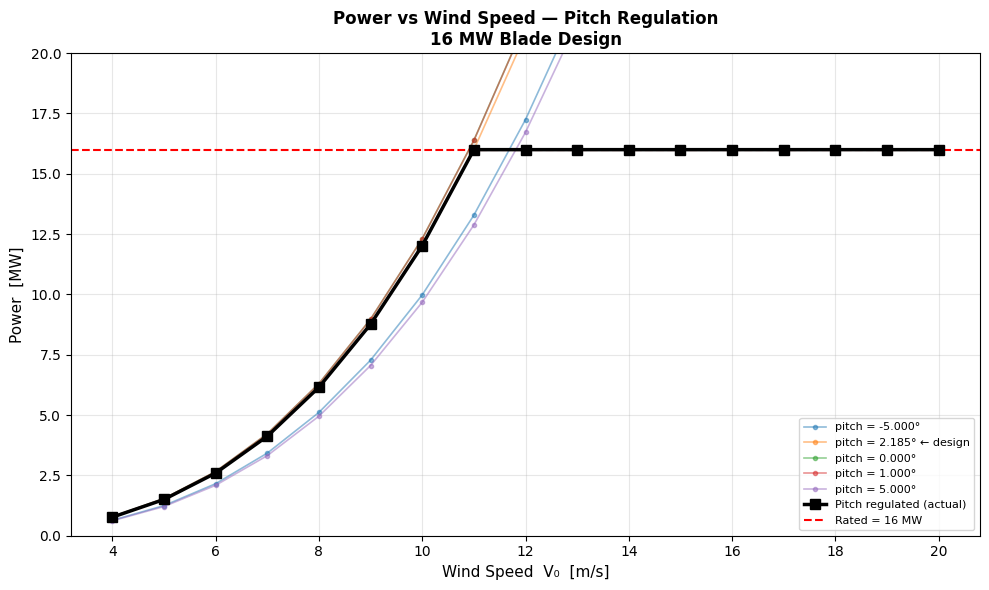

In [14]:
V0_range = np.arange(4, 21, 1)
pitches  = [-5.0, pitch_optimal, 0.0, 1.0, 5.0]

fig, ax = plt.subplots(figsize=(10, 6))

# Fixed-pitch curves
for pitch in pitches:
    P_list = []
    for V0 in V0_range:
        P, *_ = rotor_bem(r_final, beta_final, chord_final,
                          airfoil_names_final, polar_database,
                          V0=V0, TSR=TSR, B=B, rho=rho_air,
                          R_tip_override=R_design, pitch_deg=pitch)
        P_list.append(P/1e6)
    lbl = f'pitch = {pitch:.3f}°' + (' ← design' if pitch == pitch_optimal else '')
    ax.plot(V0_range, P_list, '-o', ms=3, lw=1.2, alpha=0.5, label=lbl)

# Regulated curve
P_regulated = []
for V0 in V0_range:
    P0, *_ = rotor_bem(
        r_final, beta_final, chord_final,
        airfoil_names_final, polar_database,
        V0=V0, TSR=TSR, B=B, rho=rho_air,
        R_tip_override=R_design, pitch_deg=pitch_optimal)

    if P0/1e6 <= 16.02:
        P_regulated.append(P0/1e6)   # ← Low wind speed: actual power
    else:
        def err(p):
            P, *_ = rotor_bem(
                r_final, beta_final, chord_final,
                airfoil_names_final, polar_database,
                V0=V0, TSR=TSR, B=B, rho=rho_air,
                R_tip_override=R_design, pitch_deg=p)
            return P/1e6 - 16.0

        upper = 15.0
        while err(upper) > 0 and upper < 45.0:
            upper += 5.0

        p_opt = brentq(err, pitch_optimal, upper, xtol=1e-3)
        P_regulated.append(16.0)     # ← High wind speed: maintained at 16 MW

ax.plot(V0_range, P_regulated, 's-', color='black',
        lw=2.5, ms=7, label='Pitch regulated (actual)', zorder=5)
ax.axhline(16.0, color='red', ls='--', lw=1.5, label='Rated = 16 MW')
ax.set_xlabel('Wind Speed  V₀  [m/s]', fontsize=11)
ax.set_ylabel('Power  [MW]', fontsize=11)
ax.set_title('Power vs Wind Speed — Pitch Regulation\n16 MW Blade Design',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 20)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'task2_power_curve.png'), dpi=150)
plt.show()

---
# 9. Run BEM

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# RUN BEM AT NOMINAL CONDITION
# ══════════════════════════════════════════════════════════════════════════════

# P_final, T_final, Q_final, CP_final, CT_final, rpm_final, dist_final = rotor_bem(
#     r_final, beta_final, chord_final,
#     airfoil_names_final, polar_database,
#     V0=V0_nom, TSR=TSR, pitch_deg=0.0, B=B, rho=rho_air
# )

P_final, T_final, Q_final, CP_final, CT_final, rpm_final, dist_final = rotor_bem(
    r_final, beta_final, chord_final,
    airfoil_names_final, polar_database,
    V0=V0_nom, TSR=TSR, pitch_deg=0, B=B, rho=rho_air,
    R_tip_override=R_design  
)

print(f"\n{'═'*60}")
print("BEM RESULTS AT NOMINAL CONDITION")
print(f"{'═'*60}")
print(f"Power:        {P_final/1e6:.2f} MW")
print(f"Target:       {P_rated/1e6:.1f} MW")
print(f"Error:        {(P_final - P_rated)/P_rated * 100:+.2f}%")
print(f"")
print(f"Thrust:       {T_final/1e3:.1f} kN")
print(f"Torque:       {Q_final/1e6:.2f} MN·m")
print(f"CP:           {CP_final:.3f} (Betz = 0.593)")
print(f"CT:           {CT_final:.3f}")
print(f"RPM:          {rpm_final:.2f}")
print(f"{'═'*60}")

# Check for negative fR
neg_fR = (dist_final['fR'] < 0).sum()
if neg_fR == 0:
    print("✓ No negative fR elements!")
else:
    print(f"⚠️ {neg_fR} elements have negative fR (tip loss effect)")


════════════════════════════════════════════════════════════
BEM RESULTS AT NOMINAL CONDITION
════════════════════════════════════════════════════════════
Power:        16.39 MW
Target:       16.0 MW
Error:        +2.41%

Thrust:       2761.4 kN
Torque:       22.42 MN·m
CP:           0.441 (Betz = 0.593)
CT:           0.818
RPM:          6.98
════════════════════════════════════════════════════════════
⚠️ 2 elements have negative fR (tip loss effect)


---
# 10. Plot Results

E1 CL = 0.0001
E1 AoA = 7.86°


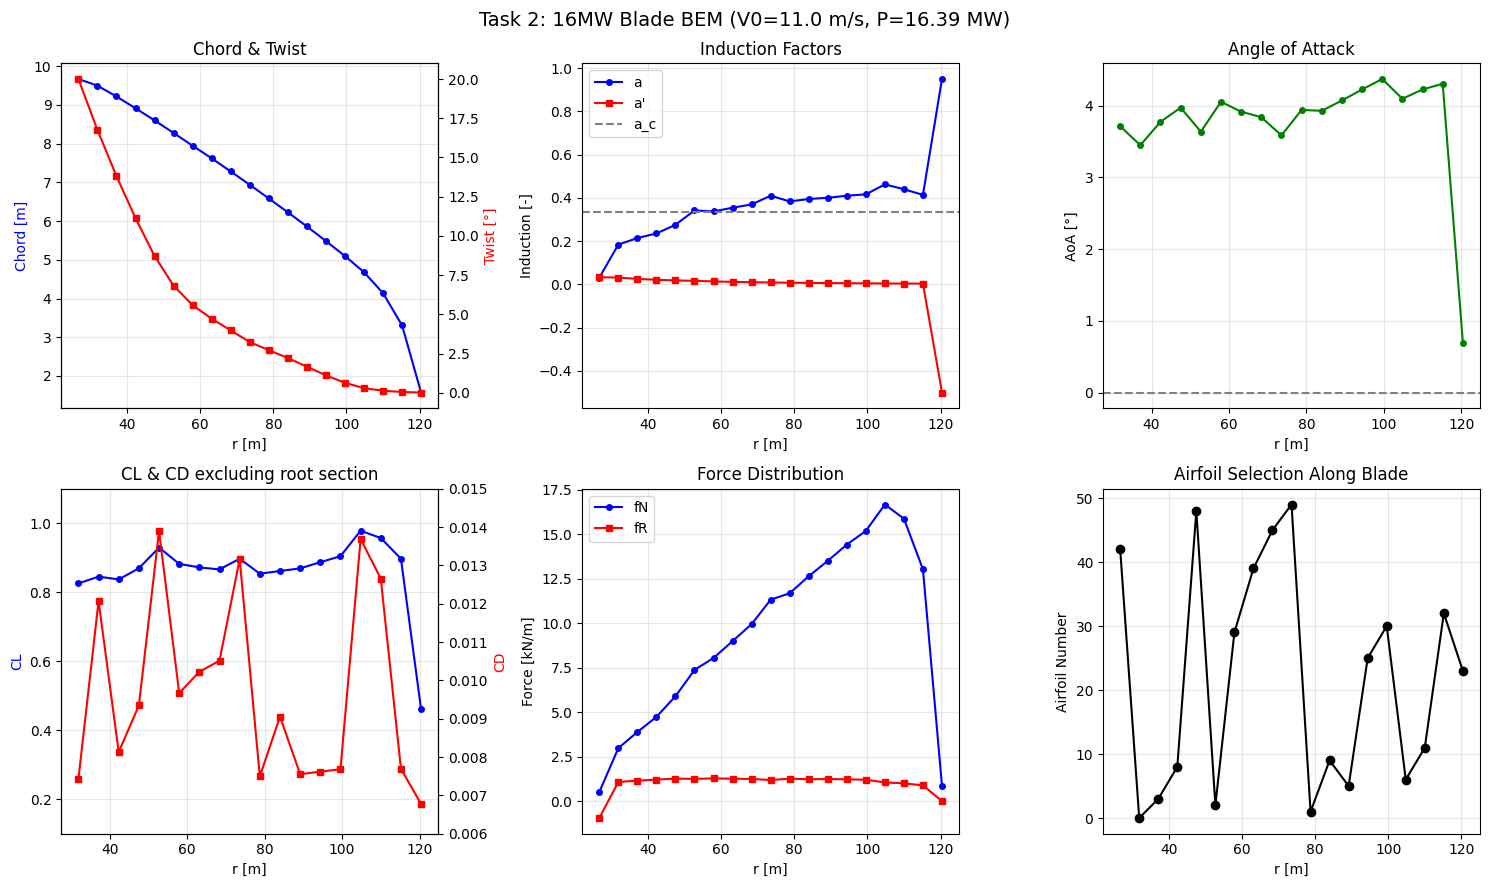

Plot saved: C:\Users\user\Downloads\sustainable energy\coding sustainable\Task2_outputs\task2_spanwise.png


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT SPANWISE DISTRIBUTIONS
# ══════════════════════════════════════════════════════════════════════════════
print(f"E1 CL = {dist_final.iloc[0]['CL']:.4f}")
print(f"E1 AoA = {dist_final.iloc[0]['aoa_deg']:.2f}°")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
dist_plot_noroot = dist_final.iloc[1:].reset_index(drop=True)

# ── 1) Chord & Twist
ax = axes[0, 0]
ax.plot(dist_final['r'], dist_final['chord'], 'b-o', ms=4)
ax.set_xlabel('r [m]'); ax.set_ylabel('Chord [m]', color='b')
ax2 = ax.twinx()
ax2.plot(dist_final['r'], dist_final['beta'], 'r-s', ms=4)
ax2.set_ylabel('Twist [°]', color='r')
ax.set_title('Chord & Twist'); ax.grid(alpha=0.3)

# ── 2) Induction Factors
ax = axes[0, 1]
ax.plot(dist_final['r'], dist_final['a'],  'b-o', ms=4, label='a')
ax.plot(dist_final['r'], dist_final['ap'], 'r-s', ms=4, label="a'")
ax.axhline(1/3, ls='--', color='gray', label='a_c')
ax.set_xlabel('r [m]'); ax.set_ylabel('Induction [-]')
ax.set_title('Induction Factors'); ax.legend(); ax.grid(alpha=0.3)

# ── 3) Angle of Attack
ax = axes[0, 2]
ax.plot(dist_plot_noroot['r'], dist_plot_noroot['aoa_deg'], 'g-o', ms=4)
ax.axhline(0, ls='--', color='gray')
ax.set_xlabel('r [m]'); ax.set_ylabel('AoA [°]')
ax.set_title('Angle of Attack'); ax.grid(alpha=0.3)

# ── 4) CL & CD
ax = axes[1, 0]
r_nr   = dist_plot_noroot['r'].values
ax.plot(r_nr, dist_plot_noroot['CL'], 'b-o', ms=4)
ax.set_xlabel('r [m]'); ax.set_ylabel('CL', color='b')
ax.set_ylim(0.5, 1.15)
ax.set_ylim(0.1, 1.1)
ax2 = ax.twinx()
ax2.plot(r_nr, dist_plot_noroot['CD'], 'r-s', ms=4)
ax2.set_ylabel('CD', color='r')
ax2.set_ylim(0.006, 0.015)
ax.set_title('CL & CD excluding root section'); ax.grid(alpha=0.3)

# ── 5) Force Distribution
ax = axes[1, 1]
ax.plot(dist_final['r'], dist_final['fN']/1e3, 'b-o', ms=4, label='fN')
ax.plot(dist_final['r'], dist_final['fR']/1e3, 'r-s', ms=4, label='fR')
ax.set_xlabel('r [m]'); ax.set_ylabel('Force [kN/m]')
ax.set_title('Force Distribution'); ax.legend(); ax.grid(alpha=0.3)

# ── 6) Airfoil Selection
ax = axes[1, 2]
thickness = [int(name.replace('COORD', '')) for name in dist_final['airfoil']]
ax.plot(dist_final['r'], thickness, 'ko-', ms=6)
ax.set_xlabel('r [m]'); ax.set_ylabel('Airfoil Number')
ax.set_title('Airfoil Selection Along Blade'); ax.grid(alpha=0.3)

fig.suptitle(f'Task 2: 16MW Blade BEM (V0={V0_nom} m/s, P={P_final/1e6:.2f} MW)',
             fontsize=14)
fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'task2_spanwise.png'), dpi=150)
plt.show()
print(f"Plot saved: {os.path.join(OUT_DIR, 'task2_spanwise.png')}")

In [17]:
# Calculate the concentrated force for each segment using trapezoidal integration
import numpy as np

r  = dist_final['r'].values       # 19 nodal positions
fN = dist_final['fN'].values      # N/m
fR = dist_final['fR'].values      # N/m

# Equivalent concentrated force at each node
FN_node = np.zeros(len(r))
FR_node = np.zeros(len(r))

for i in range(len(r) - 1):
    dr = r[i+1] - r[i]
    # Trapezoidal method: half of each segment load is assigned to each adjacent node
    FN_node[i]   += 0.5 * (fN[i] + fN[i+1]) * dr / 2
    FN_node[i+1] += 0.5 * (fN[i] + fN[i+1]) * dr / 2
    FR_node[i]   += 0.5 * (fR[i] + fR[i+1]) * dr / 2
    FR_node[i+1] += 0.5 * (fR[i] + fR[i+1]) * dr / 2

# Output for the FEA group
fea_nodes = pd.DataFrame({
    'r_m':       r,
    'FN_kN':     FN_node/1e3,    # Flapwise concentrated force
    'FR_kN':     FR_node/1e3,    # Edgewise concentrated force
    'airfoil':   dist_final['airfoil'].values,
    'chord_m':   dist_final['chord'].values,
})
print(fea_nodes.to_string(index=False))
fea_nodes.to_csv(os.path.join(OUT_DIR, 'task_fea_nodal_forces.csv'),
                 index=False, float_format='%.4f')

       r_m     FN_kN    FR_kN airfoil  chord_m
 26.689655  4.527973 0.165741 COORD42 9.667586
 31.895785 13.454139 3.062277 COORD00 9.495784
 37.101916 20.137721 5.962776 COORD03 9.216432
 42.308046 25.035129 6.281775 COORD08 8.912170
 47.514176 31.084543 6.479984 COORD48 8.598946
 52.720307 37.320964 6.547828 COORD02 8.274452
 57.926437 42.226832 6.581117 COORD29 7.944423
 63.132567 46.813828 6.554340 COORD39 7.619073
 68.338697 52.320273 6.417406 COORD45 7.280543
 73.544828 57.605269 6.344379 COORD49 6.936938
 78.750958 61.582910 6.421205 COORD01 6.584107
 83.957088 65.669727 6.446639 COORD09 6.226202
 89.163218 70.351178 6.413366 COORD05 5.860653
 94.369349 74.852737 6.361200 COORD25 5.483703
 99.575479 79.973675 6.083451 COORD30 5.096736
104.781609 83.805253 5.589786 COORD06 4.680575
109.987739 79.961083 5.111284 COORD11 4.139203
115.193870 55.677328 3.592475 COORD32 3.306222
120.400000 18.068185 1.144369 COORD23 1.571724


In [18]:
import os
CLD_FOLDER = r"C:\Users\user\Downloads\sustainable energy\Deisgn coursework\Design shape folder\Airfoil-Coords-CLD\CLD"

cld_files = sorted([f for f in os.listdir(CLD_FOLDER) if f.endswith('.txt')])
print(f"Total files: {len(cld_files)}")
for f in cld_files:
    print(f"  {f}")
    
al04, cl04, cd04 = read_polar(os.path.join(CLD_FOLDER, 'CLD04.txt'))
al42, cl42, cd42 = polar_database['COORD42']

print(f"{'':12} {'CL@4°':>8} {'CD@4°':>9} {'CL/CD':>8}")
print("─" * 42)
for name, al, cl, cd in [('CLD42', al42, cl42, cd42),
                           ('CLD04', al04, cl04, cd04)]:
    cl4 = np.interp(4.0, al, cl)
    cd4 = np.interp(4.0, al, cd)
    print(f"{name:<12} {cl4:>8.4f} {cd4:>9.5f} {cl4/cd4:>8.1f}")

Total files: 50
  CLD00.txt
  CLD01.txt
  CLD02.txt
  CLD03.txt
  CLD04.txt
  CLD05.txt
  CLD06.txt
  CLD07.txt
  CLD08.txt
  CLD09.txt
  CLD10.txt
  CLD11.txt
  CLD12.txt
  CLD13.txt
  CLD14.txt
  CLD15.txt
  CLD16.txt
  CLD17.txt
  CLD18.txt
  CLD19.txt
  CLD20.txt
  CLD21.txt
  CLD22.txt
  CLD23.txt
  CLD24.txt
  CLD25.txt
  CLD26.txt
  CLD27.txt
  CLD28.txt
  CLD29.txt
  CLD30.txt
  CLD31.txt
  CLD32.txt
  CLD33.txt
  CLD34.txt
  CLD35.txt
  CLD36.txt
  CLD37.txt
  CLD38.txt
  CLD39.txt
  CLD40.txt
  CLD41.txt
  CLD42.txt
  CLD43.txt
  CLD44.txt
  CLD45.txt
  CLD46.txt
  CLD47.txt
  CLD48.txt
  CLD49.txt
                CL@4°     CD@4°    CL/CD
──────────────────────────────────────────
CLD42          0.0001   0.35000      0.0
CLD04          0.8609   0.00752    114.5


C:\Users\user\AppData\Local\Temp\ipykernel_132788\1836440913.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_rotor = np.trapz(dP_dr, r)


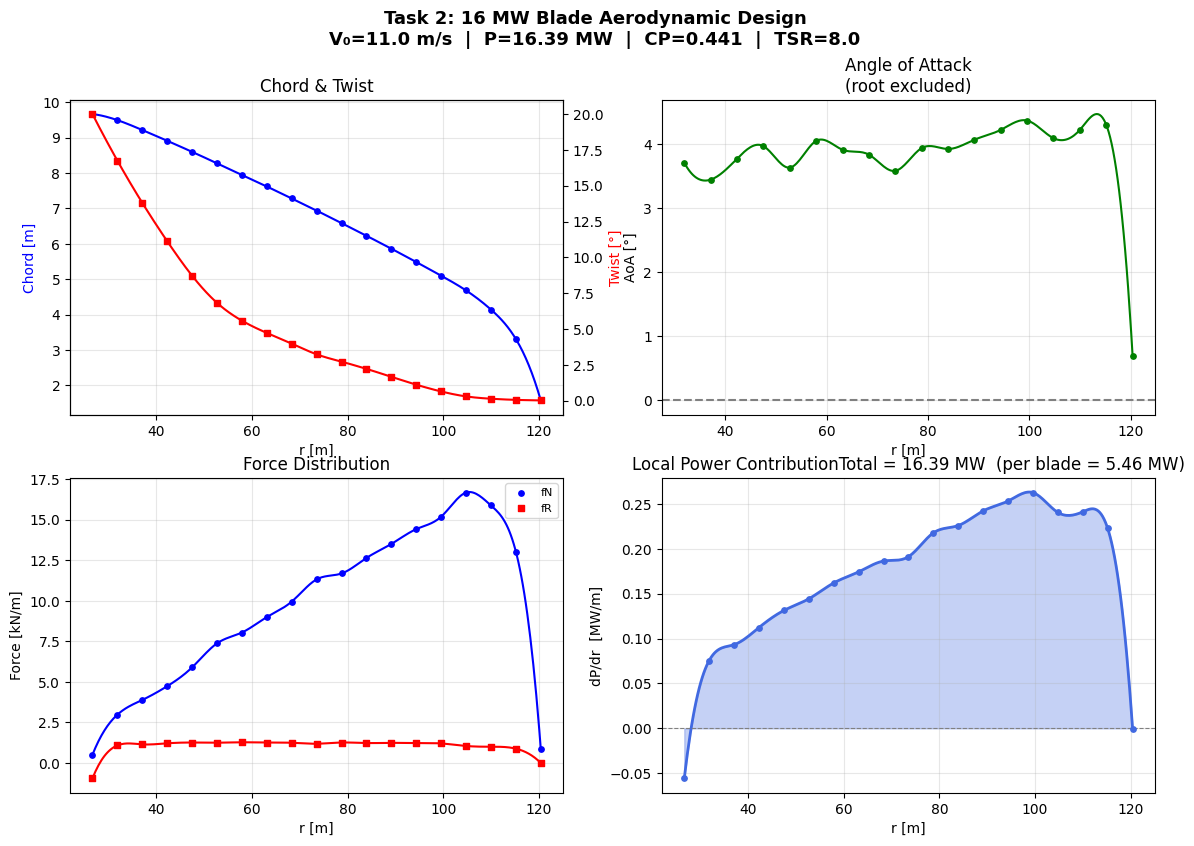

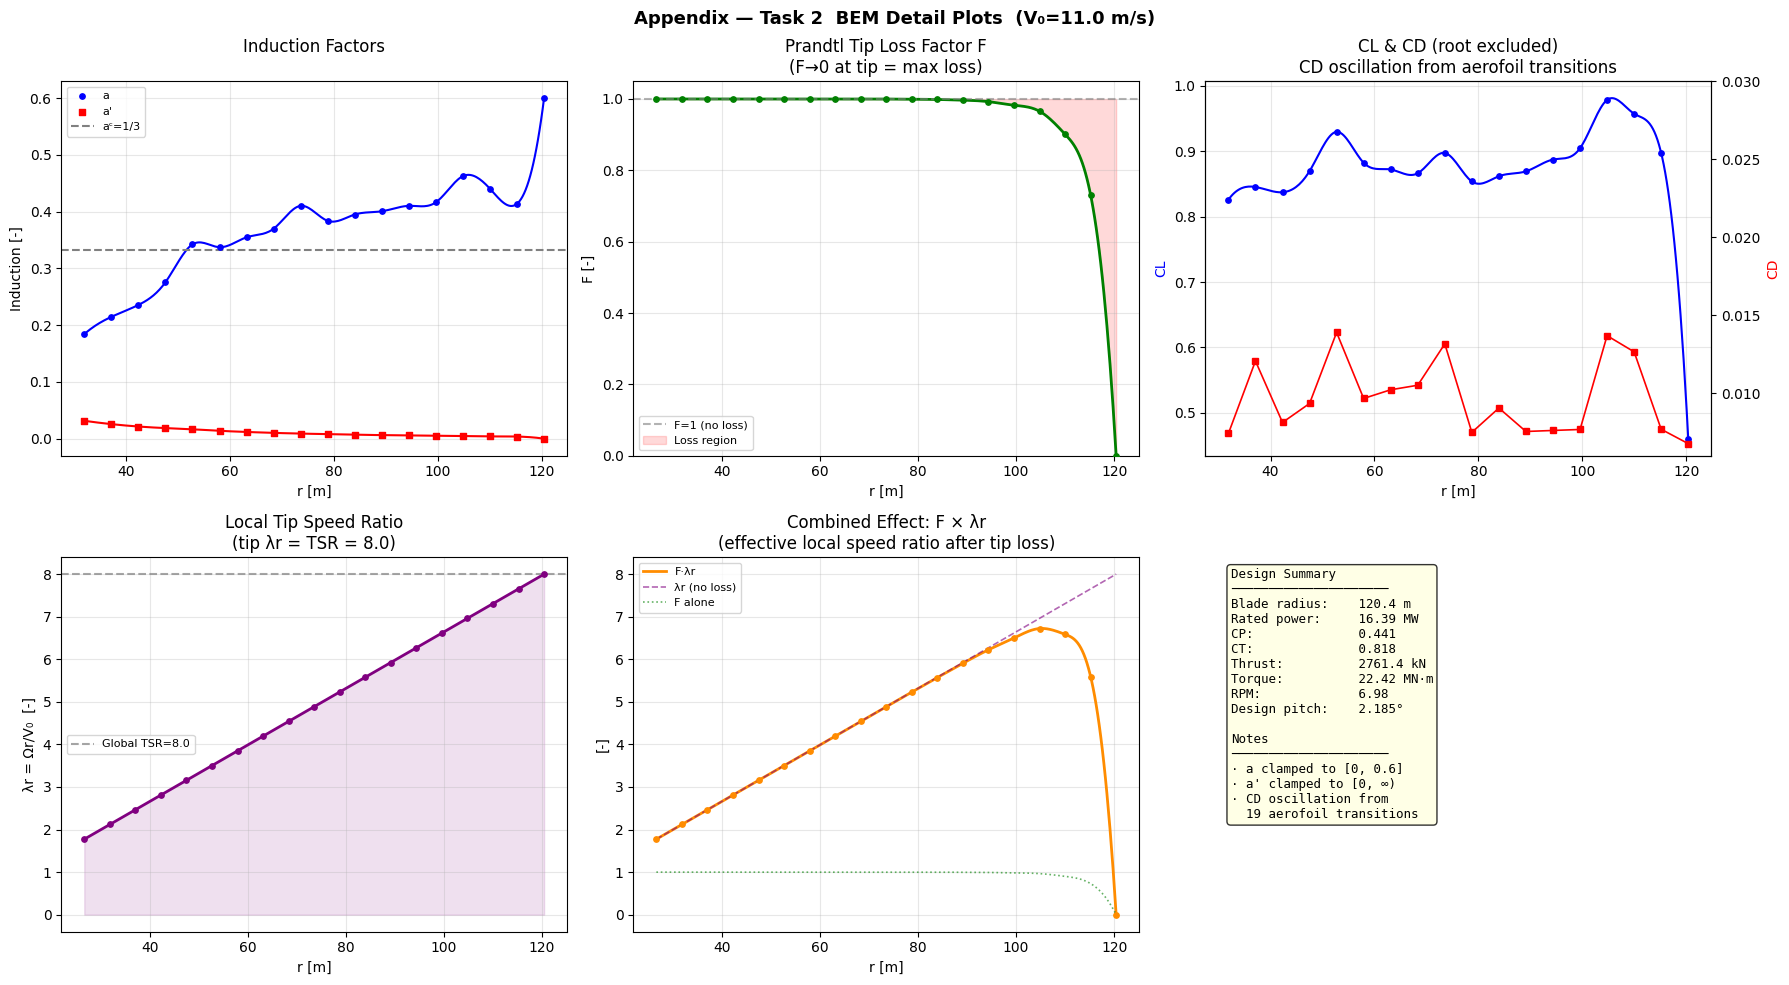

Appendix slide saved → task2_appendix_slide.png


In [19]:
from scipy.interpolate import make_interp_spline

# ── Shared data, keeping the original variables ────────────────────────────────────
r        = dist_final['r'].values
F        = dist_final['F'].values
a        = np.clip(dist_final['a'].values,  0.0, 0.6)   # clamp
ap       = np.clip(dist_final['ap'].values, 0.0, None)
aoa      = dist_final['aoa_deg'].values
CL       = dist_final['CL'].values
CD       = dist_final['CD'].values
fN       = dist_final['fN'].values
fR       = dist_final['fR'].values
chord    = dist_final['chord'].values
beta     = dist_final['beta'].values
lambda_r = Omega * r / V0_nom
dP_dr    = B * fR * r * Omega
dT_dr    = B * fN

# Version excluding the root and tip, used for AoA / induction plots
r_mid   = r[1:]
aoa_mid = aoa[1:]
a_mid   = a[1:]
ap_mid  = ap[1:]

# Version excluding the root only, used for CL/CD plots
r_nr  = r[1:]
CL_nr = CL[1:]
CD_nr = CD[1:]

def spl(x, y, n=300, k=3):
    xs = np.linspace(x.min(), x.max(), n)
    return xs, make_interp_spline(x, y, k=k)(xs)

P_rotor = np.trapz(dP_dr, r)

# ══════════════════════════════════════════════════════════════════
# FIGURE 1 — MAIN SLIDE  (2×2)
# ══════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 9))
fig1.suptitle(
    f'Task 2: 16 MW Blade Aerodynamic Design\n'
    f'V₀={V0_nom} m/s  |  P={P_final/1e6:.2f} MW  |  '
    f'CP={CP_final:.3f}  |  TSR={TSR}',
    fontsize=13, fontweight='bold'
)

# ── [0,0] Chord & Twist ───────────────────────────────────────────
ax = axes1[0, 0]
ax.scatter(r, chord, color='b', s=15, zorder=5)
rs, cs = spl(r, chord); ax.plot(rs, cs, 'b-', lw=1.5)
ax.set_xlabel('r [m]'); ax.set_ylabel('Chord [m]', color='b')
ax2 = ax.twinx()
ax2.scatter(r, beta, color='r', s=15, marker='s', zorder=5)
rs, bs = spl(r, beta); ax2.plot(rs, bs, 'r-', lw=1.5)
ax2.set_ylabel('Twist [°]', color='r')
ax.set_title('Chord & Twist'); ax.grid(alpha=0.3)

# ── [0,1] AoA ────────────────────────────────────────────────────
ax = axes1[0, 1]

mask = np.ones(len(r), dtype=bool)
mask[0] = False   # Exclude root only

# Use the same mask for both scatter and spline, while keeping the tip
ax.scatter(r[mask], aoa[mask], color='g', s=15, zorder=5)
rs, aoas = spl(r[mask], aoa[mask])
ax.plot(rs, aoas, 'g-', lw=1.5)

ax.axhline(0, ls='--', color='gray')
ax.set_xlabel('r [m]'); ax.set_ylabel('AoA [°]')
ax.set_title('Angle of Attack\n(root excluded)')
ax.grid(alpha=0.3)

# ── [1,0] Force Distribution ──────────────────────────────────────
ax = axes1[1, 0]
ax.scatter(r, fN/1e3, color='b', s=15, zorder=5, label='fN')
ax.scatter(r, fR/1e3, color='r', s=15, marker='s', zorder=5, label='fR')
rs, fns = spl(r, fN/1e3); ax.plot(rs, fns, 'b-', lw=1.5)
rs, frs = spl(r, fR/1e3); ax.plot(rs, frs, 'r-', lw=1.5)
ax.set_xlabel('r [m]'); ax.set_ylabel('Force [kN/m]')
ax.set_title('Force Distribution'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── [1,1] Local Power ─────────────────────────────────────────────
ax = axes1[1, 1]

#Calculate the spline first, then use the spline result for both filling and plotting
rs, dps = spl(r, dP_dr/1e6)

# Use the spline result for fill_between so that it matches the curve exactly
ax.fill_between(rs, dps, 0, alpha=0.3, color='royalblue')

# Curve
ax.plot(rs, dps, color='royalblue', lw=2)

# Scatter points are plotted on top
ax.scatter(r, dP_dr/1e6, color='royalblue', s=15, zorder=5)

ax.axhline(0, color='gray', lw=0.8, ls='--')   # Zero line for easier identification of negative regions
ax.set_xlabel('r [m]'); ax.set_ylabel('dP/dr  [MW/m]')
ax.set_title(f'Local Power Contribution'
             f'Total = {P_rotor/1e6:.2f} MW  '
             f'(per blade = {P_rotor/B/1e6:.2f} MW)')
ax.grid(alpha=0.3)


# ══════════════════════════════════════════════════════════════════
# FIGURE 2 — APPENDIX SLIDE  (2×3)
# ══════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
fig2.suptitle(
    f'Appendix — Task 2  BEM Detail Plots  (V₀={V0_nom} m/s)',
    fontsize=13, fontweight='bold'
)

# ── [0,0] Induction Factors (clamped, tip excluded) ───────────────
ax = axes2[0, 0]
ax.scatter(r_mid, a_mid,  color='b', s=15, zorder=5, label='a')
ax.scatter(r_mid, ap_mid, color='r', s=15, marker='s', zorder=5, label="a'")
rs, as_ = spl(r_mid, a_mid);  ax.plot(rs, as_, 'b-', lw=1.5)
rs, aps = spl(r_mid, ap_mid); ax.plot(rs, aps, 'r-', lw=1.5)
ax.axhline(1/3, ls='--', color='gray', label='aᶜ=1/3')
ax.set_xlabel('r [m]'); ax.set_ylabel('Induction [-]')
ax.set_title('Induction Factors\n')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── [0,1] Prandtl F ───────────────────────────────────────────────
ax = axes2[0, 1]
ax.scatter(r, F, color='g', s=15, zorder=5)
rs, fs = spl(r, F); ax.plot(rs, fs, 'g-', lw=2)
ax.axhline(1.0, ls='--', color='gray', alpha=0.6, label='F=1 (no loss)')
ax.fill_between(rs, fs, 1.0, alpha=0.15, color='red', label='Loss region')
ax.set_xlabel('r [m]'); ax.set_ylabel('F [-]')
ax.set_title('Prandtl Tip Loss Factor F\n(F→0 at tip = max loss)')
ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── [0,2] CL & CD ─────────────────────────────────────────────────
ax = axes2[0, 2]
ax.scatter(r_nr, CL_nr, color='b', s=15, zorder=5)
rs, cls = spl(r_nr, CL_nr); ax.plot(rs, cls, 'b-', lw=1.5)
ax.set_xlabel('r [m]'); ax.set_ylabel('CL', color='b')
ax2 = ax.twinx()
ax2.plot(r_nr, CD_nr, 'r-s', ms=4, lw=1.2)
ax2.set_ylabel('CD', color='r')
ax2.set_ylim(0.006, 0.03)
ax.set_title('CL & CD (root excluded)\nCD oscillation from aerofoil transitions')
ax.grid(alpha=0.3)

# ── [1,0] Local TSR ───────────────────────────────────────────────
ax = axes2[1, 0]
ax.scatter(r, lambda_r, color='purple', s=15, zorder=5)
rs, lrs = spl(r, lambda_r); ax.plot(rs, lrs, color='purple', lw=2)
ax.axhline(TSR, ls='--', color='gray', alpha=0.7, label=f'Global TSR={TSR}')
ax.fill_between(rs, lrs, alpha=0.12, color='purple')
ax.set_xlabel('r [m]'); ax.set_ylabel('λr = Ωr/V₀  [-]')
ax.set_title(f'Local Tip Speed Ratio\n(tip λr = TSR = {TSR})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── [1,1] F × λr ──────────────────────────────────────────────────
ax = axes2[1, 1]
Flr = F * lambda_r
ax.scatter(r, Flr, color='darkorange', s=15, zorder=5)
rs, flrs = spl(r, Flr); ax.plot(rs, flrs, color='darkorange', lw=2, label='F·λr')
rs, lrs  = spl(r, lambda_r); ax.plot(rs, lrs, 'purple', ls='--', lw=1.2, alpha=0.6, label='λr (no loss)')
rs, fs   = spl(r, F);        ax.plot(rs, fs,  'green',  ls=':',  lw=1.2, alpha=0.6, label='F alone')
ax.set_xlabel('r [m]'); ax.set_ylabel('[-]')
ax.set_title('Combined Effect: F × λr\n(effective local speed ratio after tip loss)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── [1,2] Design Summary ──────────────────────────────────────────
ax = axes2[1, 2]
ax.axis('off')
notes = (
    "Design Summary\n"
    "─────────────────────\n"
    f"Blade radius:    {R_design:.1f} m\n"
    f"Rated power:     {P_final/1e6:.2f} MW\n"
    f"CP:              {CP_final:.3f}\n"
    f"CT:              {CT_final:.3f}\n"
    f"Thrust:          {T_final/1e3:.1f} kN\n"
    f"Torque:          {Q_final/1e6:.2f} MN·m\n"
    f"RPM:             {rpm_final:.2f}\n"
    f"Design pitch:    {pitch_optimal:.3f}°\n"
    "\nNotes\n"
    "─────────────────────\n"
    "· a clamped to [0, 0.6]\n"
    "· a' clamped to [0, ∞)\n"
    "· CD oscillation from\n"
    "  19 aerofoil transitions"
)
ax.text(0.05, 0.97, notes, transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig2.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'task2_appendix_slide.png'), dpi=180, bbox_inches='tight')
plt.show()
print("Appendix slide saved → task2_appendix_slide.png")

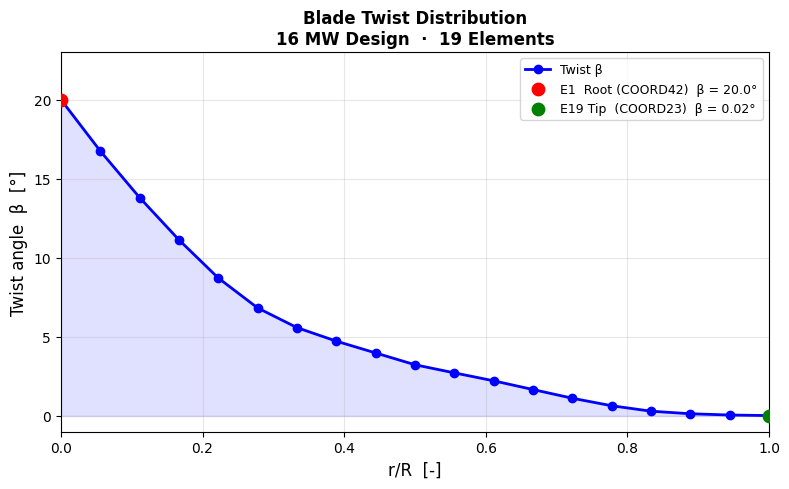

═════════════════════════════════════════════
  ANGLE OF ATTACK SUMMARY  (for FEA team)
═════════════════════════════════════════════
  Element   r [m]    r/R   AoA [°]
  ───────────────────────────────────
  1        26.69  0.000     7.857
  2        31.90  0.056     3.713
  3        37.10  0.111     3.448
  4        42.31  0.167     3.775
  5        47.51  0.222     3.972
  6        52.72  0.278     3.636
  7        57.93  0.333     4.054
  8        63.13  0.389     3.915
  9        68.34  0.444     3.839
  10       73.54  0.500     3.585
  11       78.75  0.556     3.940
  12       83.96  0.611     3.927
  13       89.16  0.667     4.072
  14       94.37  0.722     4.225
  15       99.58  0.778     4.371
  16      104.78  0.833     4.096
  17      109.99  0.889     4.226
  18      115.19  0.944     4.305
  19      120.40  1.000     0.696
  ───────────────────────────────────
  Simple mean AoA      : 3.982°
  Span-weighted mean   : 3.965°
  Min AoA (tip)        : 0.696°  at r = 120.4

C:\Users\user\AppData\Local\Temp\ipykernel_132788\2599872601.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aoa_weighted = np.trapz(aoa, r) / (r[-1] - r[0])


In [20]:
# ── Twist Angle vs r/R ───────────────────────────────────────────────────────
fig_twist, ax_twist = plt.subplots(figsize=(8, 5))

r_R = (r_final - r_final[0]) / (r_final[-1] - r_final[0])   # normalised 0→1

ax_twist.plot(r_R, beta_final, 'b-o', ms=6, lw=2, label='Twist β')
ax_twist.fill_between(r_R, beta_final, alpha=0.12, color='blue')

# Mark element 1 (root, forced to 0)
ax_twist.scatter(r_R[0],  beta_final[0],  color='red',   s=80, zorder=5,
                 label=f'E1  Root (COORD42)  β = {beta_final[0]:.1f}°')
ax_twist.scatter(r_R[-1], beta_final[-1], color='green', s=80, zorder=5,
                 label=f'E19 Tip  (COORD23)  β = {beta_final[-1]:.2f}°')

ax_twist.set_xlabel('r/R  [-]',      fontsize=12)
ax_twist.set_ylabel('Twist angle  β  [°]', fontsize=12)
ax_twist.set_title('Blade Twist Distribution\n16 MW Design  ·  19 Elements',
                   fontsize=12, fontweight='bold')
ax_twist.legend(fontsize=9)
ax_twist.grid(alpha=0.3)
ax_twist.set_xlim(0, 1)
ax_twist.set_ylim(-1, beta_final.max() * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'task2_twist_distribution.png'), dpi=150)
plt.show()
# ── Average AoA (for FEA team) ───────────────────────────────────────────────
aoa = dist_final['aoa_deg'].values
r   = dist_final['r'].values
r_R = (r - r[0]) / (r[-1] - r[0])

# Simple mean
aoa_mean = np.mean(aoa)

# Span-weighted mean (more physically meaningful)
aoa_weighted = np.trapz(aoa, r) / (r[-1] - r[0])

print("═" * 45)
print("  ANGLE OF ATTACK SUMMARY  (for FEA team)")
print("═" * 45)
print(f"  {'Element':<6} {'r [m]':>7}  {'r/R':>5}  {'AoA [°]':>8}")
print("  " + "─" * 35)
for i in range(len(r)):
    print(f"  {i+1:<6} {r[i]:>7.2f}  {r_R[i]:>5.3f}  {aoa[i]:>8.3f}")
print("  " + "─" * 35)
print(f"  Simple mean AoA      : {aoa_mean:.3f}°")
print(f"  Span-weighted mean   : {aoa_weighted:.3f}°")
print(f"  Min AoA (tip)        : {aoa.min():.3f}°  at r = {r[np.argmin(aoa)]:.1f} m")
print(f"  Max AoA (root)       : {aoa.max():.3f}°  at r = {r[np.argmax(aoa)]:.1f} m")
print("═" * 45)

In [21]:
# ── Unified variable definitions, placed before all plotting cells ────────────────
dist_plot  = dist_final.iloc[1:-1].reset_index(drop=True)  # E2~E18
r_plot     = dist_plot['r'].values
Omega_rad  = TSR * V0_nom / R_design

# Power and torque are calculated using all 19 elements, while plots show E2–E18
dQ_dr_calc = B * dist_final['fR'].values * dist_final['r'].values
dP_dr_calc = Omega_rad * dQ_dr_calc
Q_total    = np.trapz(dQ_dr_calc, dist_final['r'].values)
P_total    = np.trapz(dP_dr_calc, dist_final['r'].values)

# Used for plotting E2–E18
dQ_dr_plot = B * dist_plot['fR'].values * dist_plot['r'].values
dP_dr_plot = Omega_rad * dQ_dr_plot
V0_range = np.arange(4, 21, 1)
CP_list, CT_list = [], []

for V0 in V0_range:
    P0, T0, Q0, cp0, ct0, *_ = rotor_bem(
        r_final, beta_final, chord_final,
        airfoil_names_final, polar_database,
        V0=V0, TSR=TSR, B=B, rho=rho_air,
        R_tip_override=R_design,
        pitch_deg=pitch_optimal)

    if P0/1e6 <= 16.02:              # ← Tolerance
        CP_list.append(cp0)
        CT_list.append(ct0)
    else:
        def err(p):
            P, *_, cp, ct, __, ___ = rotor_bem(
                r_final, beta_final, chord_final,
                airfoil_names_final, polar_database,
                V0=V0, TSR=TSR, B=B, rho=rho_air,
                R_tip_override=R_design, pitch_deg=p)
            return P/1e6 - 16.0

        upper = 15.0
        while err(upper) > 0 and upper < 45.0:
            upper += 5.0

        p_opt = brentq(err, pitch_optimal, upper, xtol=1e-3)   # ← Do not add 0.1 to pitch_optimal
        _, _, _, cp_r, ct_r, *__ = rotor_bem(
            r_final, beta_final, chord_final,
            airfoil_names_final, polar_database,
            V0=V0, TSR=TSR, B=B, rho=rho_air,
            R_tip_override=R_design, pitch_deg=p_opt)
        CP_list.append(cp_r)
        CT_list.append(ct_r)

C:\Users\user\AppData\Local\Temp\ipykernel_132788\3483911202.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Q_total    = np.trapz(dQ_dr_calc, dist_final['r'].values)
C:\Users\user\AppData\Local\Temp\ipykernel_132788\3483911202.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_total    = np.trapz(dP_dr_calc, dist_final['r'].values)


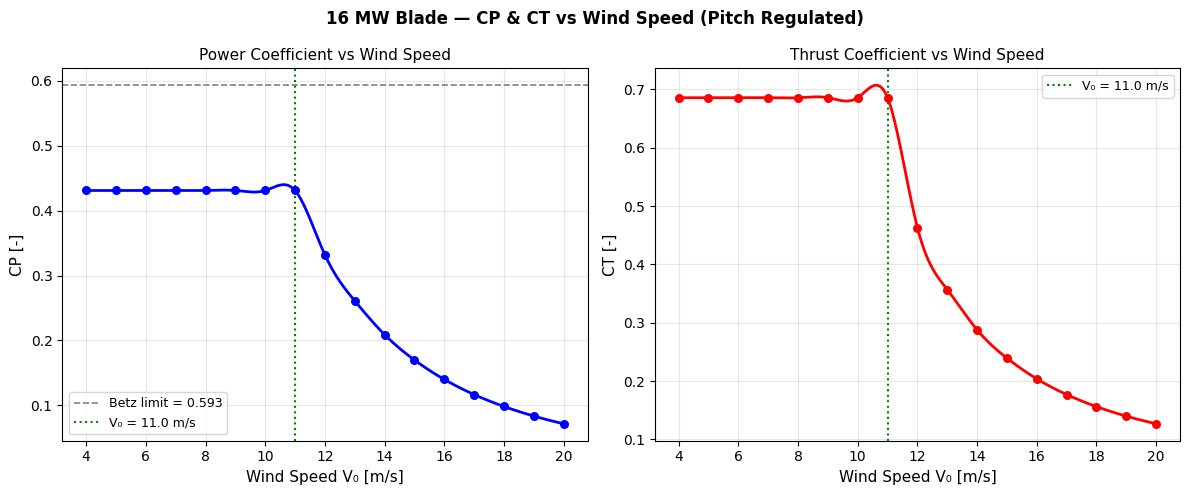

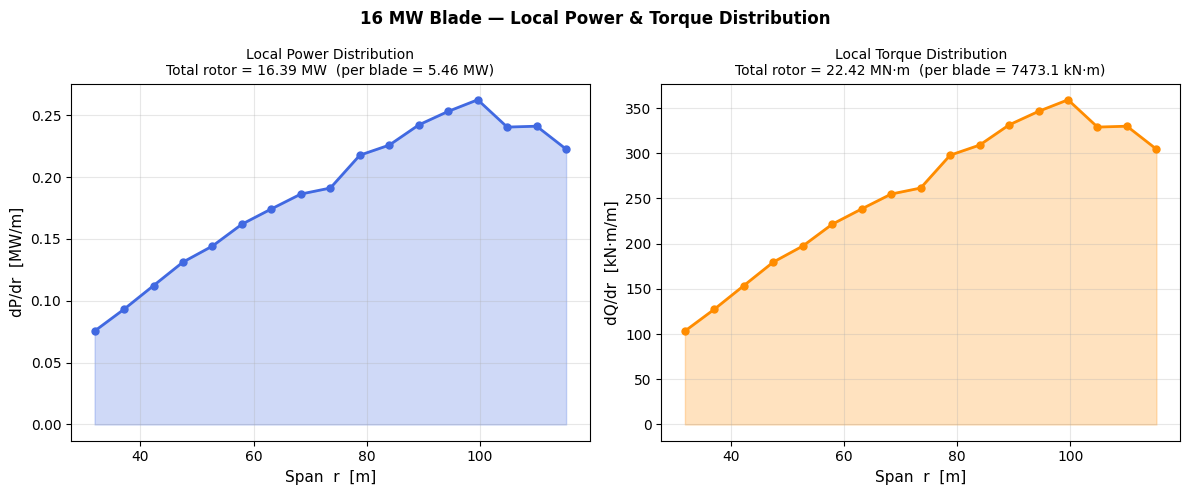

In [22]:
# PLOT 1 — CP & CT with spline smoothing
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

V0_arr = np.array(V0_range, dtype=float)
rs_v, cps = spl(V0_arr, np.array(CP_list))
ax1.scatter(V0_arr, CP_list, color='b', s=30, zorder=5)
ax1.plot(rs_v, cps, 'b-', lw=2)
ax1.axhline(0.593, color='gray', ls='--', lw=1.2, label='Betz limit = 0.593')
ax1.axvline(V0_nom, color='green', ls=':', lw=1.5, label=f'V₀ = {V0_nom} m/s')
ax1.set_xlabel('Wind Speed V₀ [m/s]', fontsize=11)
ax1.set_ylabel('CP [-]', fontsize=11)
ax1.set_title('Power Coefficient vs Wind Speed', fontsize=11)
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

rs_v, cts = spl(V0_arr, np.array(CT_list))
ax2.scatter(V0_arr, CT_list, color='r', s=30, zorder=5)
ax2.plot(rs_v, cts, 'r-', lw=2)
ax2.axvline(V0_nom, color='green', ls=':', lw=1.5, label=f'V₀ = {V0_nom} m/s')
ax2.set_xlabel('Wind Speed V₀ [m/s]', fontsize=11)
ax2.set_ylabel('CT [-]', fontsize=11)
ax2.set_title('Thrust Coefficient vs Wind Speed', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

fig1.suptitle('16 MW Blade — CP & CT vs Wind Speed (Pitch Regulated)',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'task2_CP_CT_vs_windspeed.png'), dpi=150)
plt.show()

# PLOT 3 — Power & Torque using the original o- format
dP_dr_plot = B * dist_plot['fR'].values * dist_plot['r'].values * Omega_rad
dQ_dr_plot = B * dist_plot['fR'].values * dist_plot['r'].values

fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.fill_between(r_plot, dP_dr_plot/1e6, alpha=0.25, color='royalblue')
ax1.plot(r_plot, dP_dr_plot/1e6, 'o-', color='royalblue', ms=5, lw=2)
ax1.set_xlabel('Span  r  [m]', fontsize=11)
ax1.set_ylabel('dP/dr  [MW/m]', fontsize=11)
ax1.set_title(f'Local Power Distribution\n'
              f'Total rotor = {P_total/1e6:.2f} MW  '
              f'(per blade = {P_total/B/1e6:.2f} MW)', fontsize=10)
ax1.grid(alpha=0.3)

ax2.fill_between(r_plot, dQ_dr_plot/1e3, alpha=0.25, color='darkorange')
ax2.plot(r_plot, dQ_dr_plot/1e3, 'o-', color='darkorange', ms=5, lw=2)
ax2.set_xlabel('Span  r  [m]', fontsize=11)
ax2.set_ylabel('dQ/dr  [kN·m/m]', fontsize=11)
ax2.set_title(f'Local Torque Distribution\n'
              f'Total rotor = {Q_total/1e6:.2f} MN·m  '
              f'(per blade = {Q_total/B/1e3:.1f} kN·m)', fontsize=10)
ax2.grid(alpha=0.3)

fig3.suptitle('16 MW Blade — Local Power & Torque Distribution',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'task2_power_torque_distribution.png'), dpi=150)
plt.show()

---
# 11. Save Final Results

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# SAVE FINAL DESIGN
# ══════════════════════════════════════════════════════════════════════════════

# Save geometry
final_geom = pd.DataFrame({
    'element': range(1, len(r_final)+1),
    'r_m': r_final,
    'chord_m': chord_final,
    'twist_deg': beta_final,
    'airfoil': airfoil_names_final
})
final_geom.to_csv(os.path.join(OUT_DIR, 'task2_final_geometry_19airfoils.csv'), index=False)

# Save distribution
dist_final.to_csv(os.path.join(OUT_DIR, 'task2_final_distribution_19airfoils.csv'), index=False)

print("✓ Final design saved!")
print(f"  Geometry: {os.path.join(OUT_DIR, 'task2_final_geometry_19airfoils.csv')}")
print(f"  Distribution: {os.path.join(OUT_DIR, 'task2_final_distribution_19airfoils.csv')}")

✓ Final design saved!
  Geometry: C:\Users\user\Downloads\sustainable energy\coding sustainable\Task2_outputs\task2_final_geometry_19airfoils.csv
  Distribution: C:\Users\user\Downloads\sustainable energy\coding sustainable\Task2_outputs\task2_final_distribution_19airfoils.csv


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# NUMERICAL CONSISTENCY CHECK TABLE
# ══════════════════════════════════════════════════════════════════════════════

Omega_check = TSR * V0_nom / R_design
P_check     = Omega_check * Q_final
A_rotor     = np.pi * R_design**2

print("=" * 65)
print(f"{'NUMERICAL CONSISTENCY CHECK':^65}")
print("=" * 65)
print(f"{'Check':<25} {'Value':>15}   {'Comment'}")
print("-" * 65)
print(f"{'V₀':<25} {V0_nom:>14.1f} m/s  Rated wind speed")
print(f"{'TSR  λ':<25} {TSR:>15.1f}   Design condition")
print(f"{'R':<25} {R_design:>14.1f} m    Blade radius")
print(f"{'Ω = λV₀/R':<25} {Omega_check:>13.3f} rad/s  Rotor angular speed")
print(f"{'RPM':<25} {Omega_check*60/(2*np.pi):>13.2f} rpm   Rotor speed")
print(f"{'Q (BEM)':<25} {Q_final/1e6:>13.2f} MN·m  From BEM integration")
print(f"{'P = ΩQ':<25} {P_check/1e6:>13.2f} MW    Matches rated power")
print(f"{'P (direct BEM)':<25} {P_final/1e6:>13.2f} MW    Direct from BEM")
print(f"{'CP':<25} {CP_final:>15.3f}   Below Betz limit")
print(f"{'Betz limit':<25} {0.593:>15.3f}   Theoretical upper bound")
print(f"{'CT':<25} {CT_final:>15.3f}   Thrust coefficient")
print(f"{'Thrust T':<25} {T_final/1e3:>13.1f} kN   Total rotor thrust")
print(f"{'Pitch angle':<25} {pitch_optimal:>13.4f} °    Design pitch")
print("-" * 65)

print("\nVERIFICATION:")
print(f"  P = ΩQ vs BEM:  {abs(P_check - P_final)/P_final*100:.3f}% difference  ",
      "✓" if abs(P_check - P_final)/P_final < 0.01 else "⚠ CHECK")
print(f"  CP < Betz:      {CP_final:.3f} < 0.593  ",
      "✓" if CP_final < 0.593 else "⚠ CHECK")
print(f"  CT reasonable:  {CT_final:.3f}  ",
      "✓" if 0.4 < CT_final < 1.2 else "⚠ CHECK")
print("=" * 65)

                   NUMERICAL CONSISTENCY CHECK                   
Check                               Value   Comment
-----------------------------------------------------------------
V₀                                  11.0 m/s  Rated wind speed
TSR  λ                                8.0   Design condition
R                                  120.4 m    Blade radius
Ω = λV₀/R                         0.731 rad/s  Rotor angular speed
RPM                                6.98 rpm   Rotor speed
Q (BEM)                           22.42 MN·m  From BEM integration
P = ΩQ                            16.39 MW    Matches rated power
P (direct BEM)                    16.39 MW    Direct from BEM
CP                                  0.441   Below Betz limit
Betz limit                          0.593   Theoretical upper bound
CT                                  0.818   Thrust coefficient
Thrust T                         2761.4 kN   Total rotor thrust
Pitch angle                      2.1847 °    Design pitch